# Clustering

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('./insurance.csv')

a) Clustering

centroids
['-0.84', '-0.30', '-0.53', '-0.58']
['0.83', '0.34', '-0.46', '0.64']
['0.06', '-0.03', '1.34', '-0.05']
cohort sizes
[498 480 360]
smoker       no  yes
cluster_nr          
0           443   55
1           323  157
2           298   62


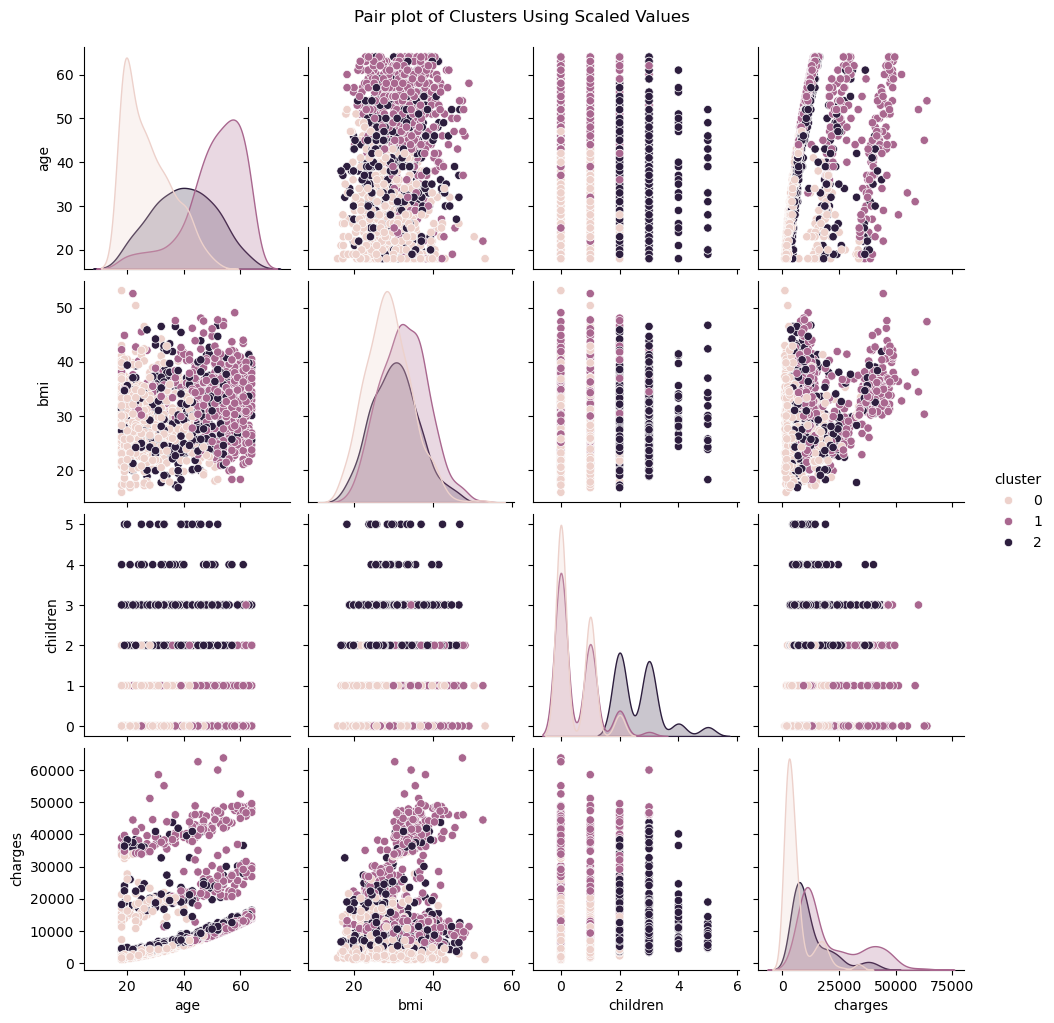

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# features and parameters  
features = ["age", "bmi", "children", "charges"]
cluster_data = data[features]
data_copy = data.copy()
cluster_no = 3

# Normalize
scaler = StandardScaler()
scaled_data= scaler.fit_transform(cluster_data)


kmeans = KMeans(n_clusters=cluster_no, random_state= 42, init='k-means++')
data_copy['cluster_nr'] = kmeans.fit_predict(scaled_data)

k_labels = kmeans.labels_
centroids = kmeans.cluster_centers_
cohort_sizes = np.bincount(k_labels)

original_centroid_values = scaler.inverse_transform(centroids)

# count the number of smoker and non-smoker
cluster_smoker_counts = data_copy.groupby(['cluster_nr', 'smoker']).size().unstack(fill_value=0)

df = pd.DataFrame(data, columns=features)
df["cluster"] = k_labels  # Add cluster labels to the DataFrame


print("centroids")
for row in centroids:
    print([f"{p:.2f}" for p in row])

print("cohort sizes")
print(cohort_sizes)

print(cluster_smoker_counts)
sns.pairplot(df, vars=features, hue="cluster")
plt.suptitle("Pair plot of Clusters Using Scaled Values",y=1.02)
plt.show()